In [1]:
import os, matplotlib.pyplot as plt, joblib
os.environ["OMP_NUM_THREADS"] = "1"
#useful on linux to avoid numpy multithreading
 
import numpy as np, scipy, xarray as xr

# import the class definition from the 1st step
#from step1_data_preparation import CustomPreprocessor

#### **Load data**

In [2]:
# Path to the prepared data folder
processed_data_path=os.path.expanduser('~/data/srnn_data/MPI-ESM-z100')
#CP = joblib.load(os.path.join(processed_data_path,'CP.jpkl'))

# Training data
pcs,kpcs,init_length = joblib.load(os.path.join(processed_data_path,'training_data.jpkl'))
pcs=pcs[:,init_length:, :]
kpcs=kpcs[:,init_length:, :]

# Evaluation data
evaluation_pcs, evaluation_kpcs,init_length = joblib.load(os.path.join(processed_data_path,'evaluation_data.jpkl'))
evaluation_pcs=evaluation_pcs[:,init_length:, :]
evaluation_kpcs=evaluation_kpcs[:,init_length:, :]

# Emulated data
predicted_pcs_a,predicted_kpcs_a = joblib.load(os.path.join(processed_data_path,'predicted_data_4a.jpkl'))
predicted_kpcs_b = joblib.load(os.path.join(processed_data_path,'predicted_data_4b.jpkl'))


#### **Plot training data**

##### Time series of kernel PCs

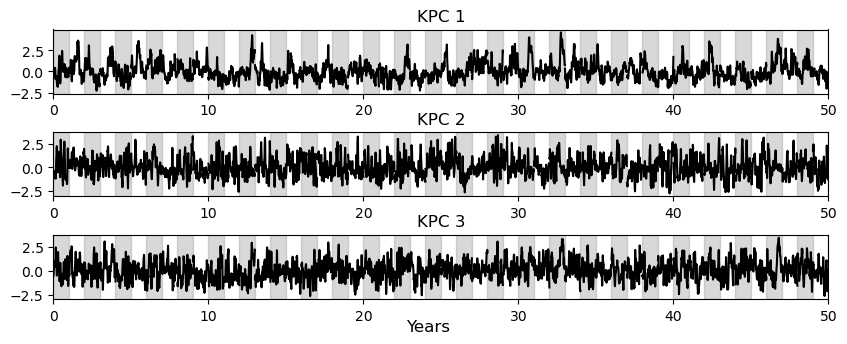

In [3]:
nsamples,nt,d=kpcs.shape
time=np.arange(nsamples*nt).reshape((nsamples,nt))/nt#+1958  
    
fig=plt.figure(figsize=(10,3.5))
fig.subplots_adjust(hspace=0.6)
for i in range(d):
    ax=fig.add_subplot(d,1,i+1)
    ax.set_title('KPC %d'%(i+1))
    for j in range(0,time.shape[0]): 
        if j%2==0:
            ax.axvspan(time[j,0], time[j,-1], alpha=0.3, color='gray')
    ax.plot(time.T,kpcs[...,i].T,'-k',label='Data')
        
    ax.set_xlim(time[0,0],time[0,0]+50)#1990,2023)
    
fig.supxlabel('Years')
plt.savefig('fig_kpcs_ts_tr.png')
plt.show()    
plt.close(fig) 

##### 2D projections of kernel PCs

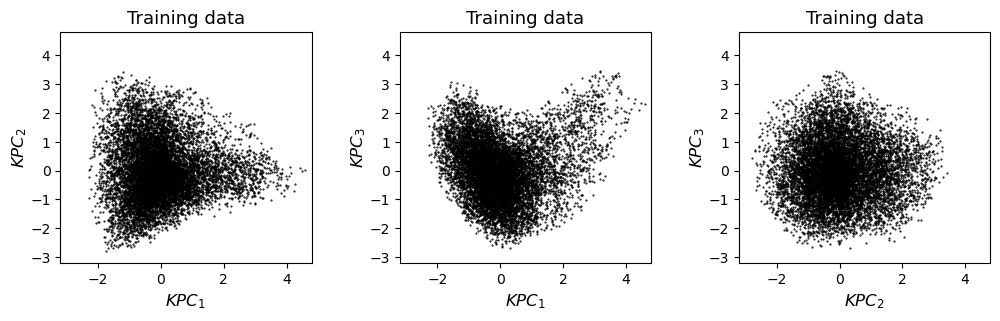

In [4]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3.5))
fig.subplots_adjust(
    left=0.06,
    right=0.99,
    bottom=0.22,
    wspace=0.35
)

k = 0
for i in range(3):
    for j in range(i + 1, 3):
        ax = axs[k]
        k += 1

        ax.plot(
            kpcs[:, :, i].flatten(),
            kpcs[:, :, j].flatten(),
            '.k',
            markersize=1
        )

        ax.set_xlabel(f"$KPC_{i+1}$", fontsize=12)
        ax.set_ylabel(f"$KPC_{j+1}$", fontsize=12, labelpad=1)
        ax.set_title('Training data', fontsize=13)

        ax.set_xlim(-3.2, 4.8)
        ax.set_ylim(-3.2, 4.8)

plt.savefig('fig_kpcs_2d_tr.png', dpi=300)
plt.show()

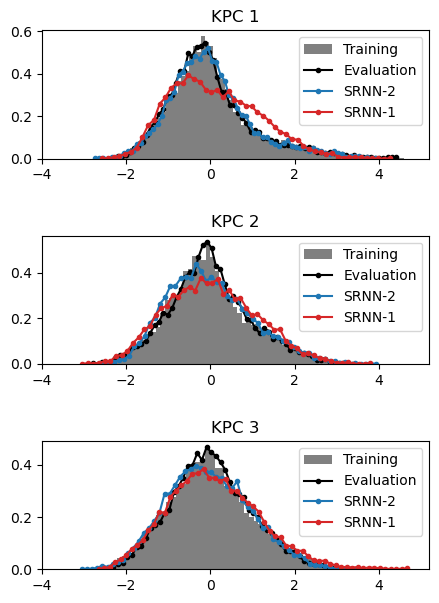

In [5]:
fig=plt.figure(figsize=(5,7))
fig.subplots_adjust(hspace=0.6)
for i in range(d):
    ax=fig.add_subplot(d,1,i+1)
    ax.set_title('KPC %d'%(i+1))
    ax.hist(kpcs[...,i].flatten(),bins='auto',density=True,color='gray',label='Training')
    ax.set_xlim(-4,5.2)
    h,b=np.histogram(evaluation_kpcs[...,i].flatten(),bins='auto',density=True)
    ax.plot(0.5*(b[1:]+b[:-1]),h,'.-',color='black',label='Evaluation')    
    h,b=np.histogram(predicted_kpcs_a[...,i].flatten(),bins='auto',density=True)
    ax.plot(0.5*(b[1:]+b[:-1]),h,'.-',color='tab:blue',label='SRNN-2')
    h,b=np.histogram(predicted_kpcs_b[...,i].flatten(),bins='auto',density=True)
    ax.plot(0.5*(b[1:]+b[:-1]),h,'.-',color='tab:red',label='SRNN-1')    
    ax.legend()
plt.savefig('fig_histograms.png')
plt.show()     

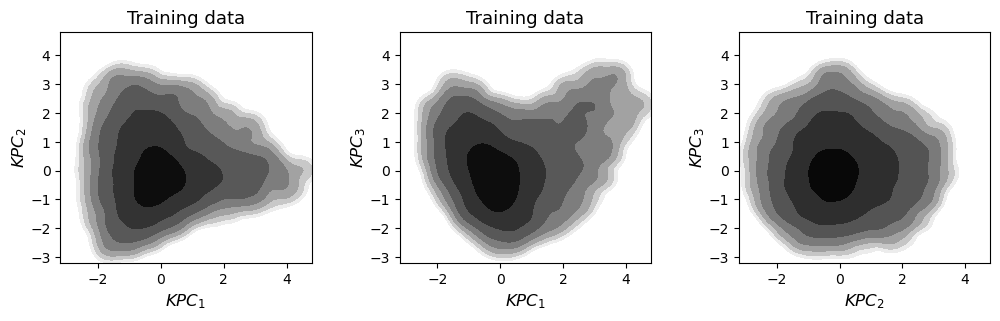

In [6]:
import matplotlib.colors as colors
from scipy.stats import gaussian_kde

def plot_kde2d(fig,ax, data1, data2, range=[[-4, 5.2], [-4, 5.2]], gridsize=100):
    # Prepare data
    x = data1.flatten()
    y = data2.flatten()
    values = np.vstack([x, y])

    # KDE
    kde = gaussian_kde(values)

    # Evaluation grid
    xgrid = np.linspace(range[0][0], range[0][1], gridsize)
    ygrid = np.linspace(range[1][0], range[1][1], gridsize)
    X, Y = np.meshgrid(xgrid, ygrid)
    positions = np.vstack([X.ravel(), Y.ravel()])

    Z = kde(positions).reshape(X.shape)

    # Log normalization parameters
    lmax = np.ceil(np.log10(Z.max()))
    norders = 4

    # Plot
    cs = ax.contourf(X, Y, Z,cmap='binary',norm=colors.LogNorm(vmin=10.**(lmax - norders), vmax=Z.max()),levels=np.logspace(lmax-norders,lmax,norders*2+1),extend='max')
    #cs = ax.pcolormesh(X, Y, Z,cmap='binary',norm=colors.LogNorm(vmin=10.**(lmax - norders), vmax=Z.max()),shading='auto')

    #fig.colorbar(cs, ax=ax,orientation='horizontal')


fig, axs = plt.subplots(1, 3, figsize=(10, 3.5))
fig.subplots_adjust(
    left=0.06,
    right=0.99,
    bottom=0.22,
    wspace=0.35
)

k = 0
for i in range(3):
    for j in range(i + 1, 3):
        ax = axs[k]
        k += 1

        plot_kde2d(fig, ax,kpcs[...,i],kpcs[...,j])

        ax.set_xlabel(f"$KPC_{i+1}$", fontsize=12)
        ax.set_ylabel(f"$KPC_{j+1}$", fontsize=12, labelpad=1)
        ax.set_title('Training data', fontsize=13)

        ax.set_xlim(-3.2, 4.8)
        ax.set_ylim(-3.2, 4.8)

plt.savefig('fig_kpcs_kde2d_tr.png', dpi=300)
plt.show()


#### Observed (evaluation) and emulated time series

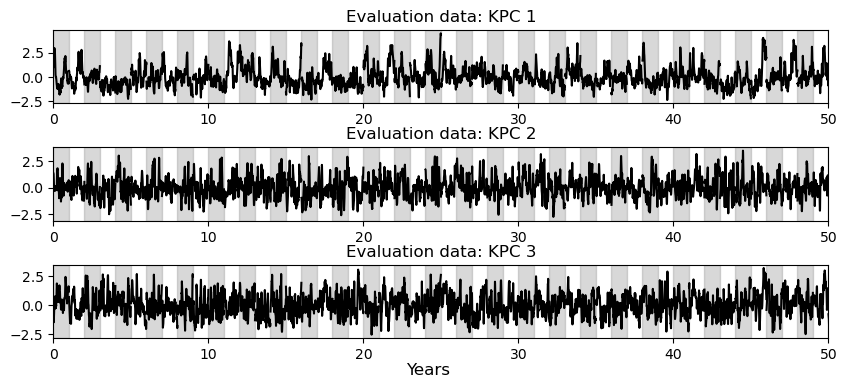

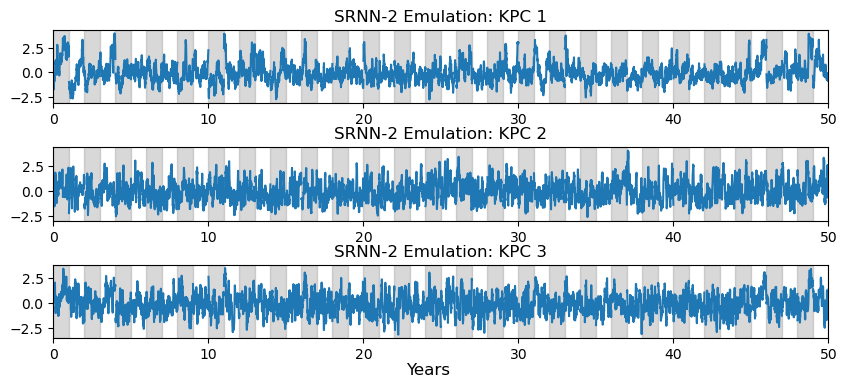

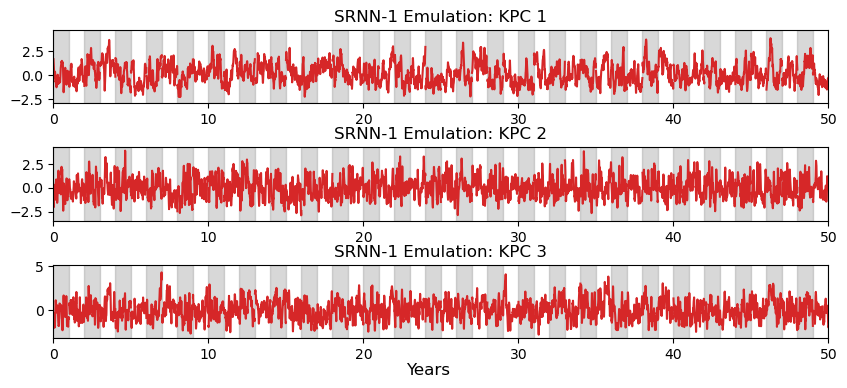

In [7]:
time=np.arange(nsamples*nt).reshape((nsamples,nt))/nt#+1958  
    
fig=plt.figure(figsize=(10,4))
fig.subplots_adjust(hspace=0.6)
for i in range(d):
    ax=fig.add_subplot(d,1,i+1)
    ax.set_title('Evaluation data: KPC %d'%(i+1))
    for j in range(0,time.shape[0]): 
        if j%2==0:
            ax.axvspan(time[j,0], time[j,-1], alpha=0.3, color='gray')
    ax.plot(time.T,evaluation_kpcs[...,i].T,'-k',label='Data')
        
    ax.set_xlim(time[0,0],time[0,0]+50)#1990,2023)
    
fig.supxlabel('Years')
plt.savefig('fig_kpcs_ts_eval.png')
plt.show()    
plt.close(fig) 

time=np.arange(nsamples*nt).reshape((nsamples,nt))/nt#+1958  
    
fig=plt.figure(figsize=(10,4))
fig.subplots_adjust(hspace=0.6)
for i in range(d):
    ax=fig.add_subplot(d,1,i+1)
    ax.set_title('SRNN-2 Emulation: KPC %d'%(i+1))
    for j in range(0,time.shape[0]): 
        if j%2==0:
            ax.axvspan(time[j,0], time[j,-1], alpha=0.3, color='gray')
    ax.plot(time.T,predicted_kpcs_a[...,i].T,'-',color='tab:blue',label='SRNN')
        
    ax.set_xlim(time[0,0],time[0,0]+50)#1990,2023)
    
fig.supxlabel('Years')
plt.savefig('fig_kpcs_ts_srnn_a.png')
plt.show()    
plt.close(fig) 


fig=plt.figure(figsize=(10,4))
fig.subplots_adjust(hspace=0.6)
for i in range(d):
    ax=fig.add_subplot(d,1,i+1)
    ax.set_title('SRNN-1 Emulation: KPC %d'%(i+1))
    for j in range(0,time.shape[0]): 
        if j%2==0:
            ax.axvspan(time[j,0], time[j,-1], alpha=0.3, color='gray')
    ax.plot(time.T,predicted_kpcs_b[...,i].T,'-',color='tab:red',label='SRNN')
        
    ax.set_xlim(time[0,0],time[0,0]+50)#1990,2023)
    
fig.supxlabel('Years')
plt.savefig('fig_kpcs_ts_srnn_b.png')
plt.show()    
plt.close(fig) 

##### **Plot observed and emulated distributions of Kernel PCs**

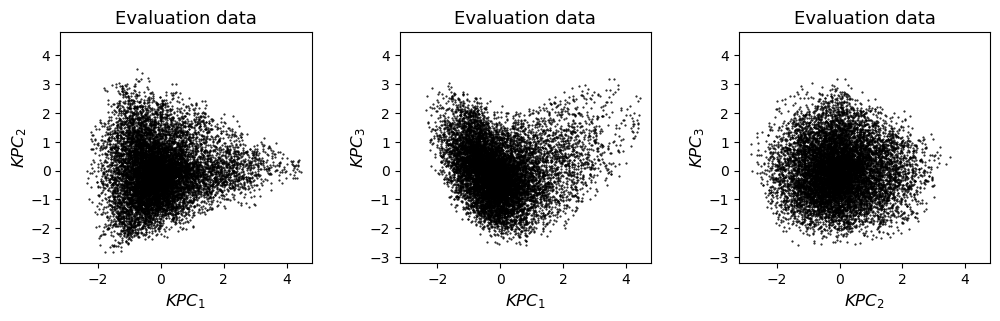

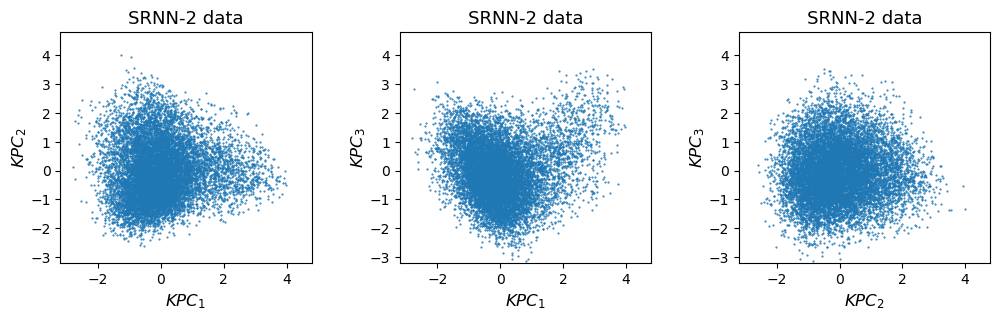

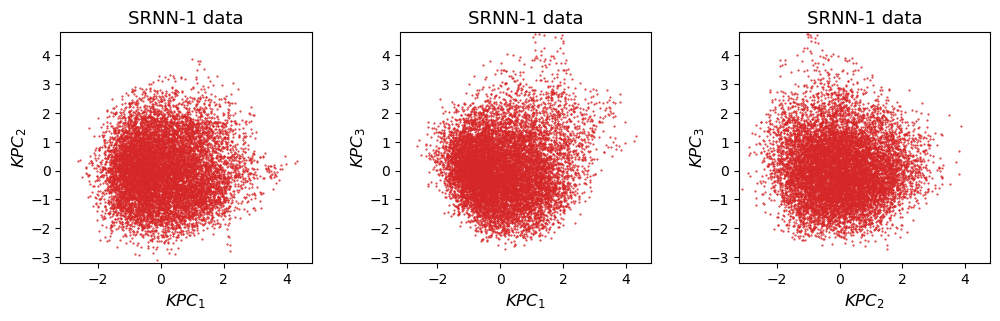

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3.5))
fig.subplots_adjust(
    left=0.06,
    right=0.99,
    bottom=0.22,
    wspace=0.35
)

k = 0
for i in range(3):
    for j in range(i + 1, 3):
        ax = axs[k]
        k += 1

        ax.plot(
            evaluation_kpcs[:, :, i].flatten(),
            evaluation_kpcs[:, :, j].flatten(),
            '.k',
            markersize=1
        )

        ax.set_xlabel(f"$KPC_{i+1}$", fontsize=12)
        ax.set_ylabel(f"$KPC_{j+1}$", fontsize=12, labelpad=1)
        ax.set_title('Evaluation data', fontsize=13)

        ax.set_xlim(-3.2, 4.8)
        ax.set_ylim(-3.2, 4.8)

plt.savefig('fig_kpcs_2d_eval.png', dpi=300)
plt.show()








fig, axs = plt.subplots(1, 3, figsize=(10, 3.5))
fig.subplots_adjust(
    left=0.06,
    right=0.99,
    bottom=0.22,
    wspace=0.35
)

k = 0
for i in range(3):
    for j in range(i + 1, 3):
        ax = axs[k]
        k += 1

        ax.plot(
            predicted_kpcs_a[:, :, i].flatten(),
            predicted_kpcs_a[:, :, j].flatten(),
            '.',color='tab:blue',
            markersize=1
        )

        ax.set_xlabel(f"$KPC_{i+1}$", fontsize=12)
        ax.set_ylabel(f"$KPC_{j+1}$", fontsize=12, labelpad=1)
        ax.set_title('SRNN-2 data', fontsize=13)

        ax.set_xlim(-3.2, 4.8)
        ax.set_ylim(-3.2, 4.8)

plt.savefig('fig_kpcs_2d_srnn_a.png', dpi=300)
plt.show()











fig, axs = plt.subplots(1, 3, figsize=(10, 3.5))
fig.subplots_adjust(
    left=0.06,
    right=0.99,
    bottom=0.22,
    wspace=0.35
)

k = 0
for i in range(3):
    for j in range(i + 1, 3):
        ax = axs[k]
        k += 1

        ax.plot(
            predicted_kpcs_b[:, :, i].flatten(),
            predicted_kpcs_b[:, :, j].flatten(),
            '.',color='tab:red',
            markersize=1
        )

        ax.set_xlabel(f"$KPC_{i+1}$", fontsize=12)
        ax.set_ylabel(f"$KPC_{j+1}$", fontsize=12, labelpad=1)
        ax.set_title('SRNN-1 data', fontsize=13)

        ax.set_xlim(-3.2, 4.8)
        ax.set_ylim(-3.2, 4.8)

plt.savefig('fig_kpcs_2d_srnn_b.png', dpi=300)
plt.show()



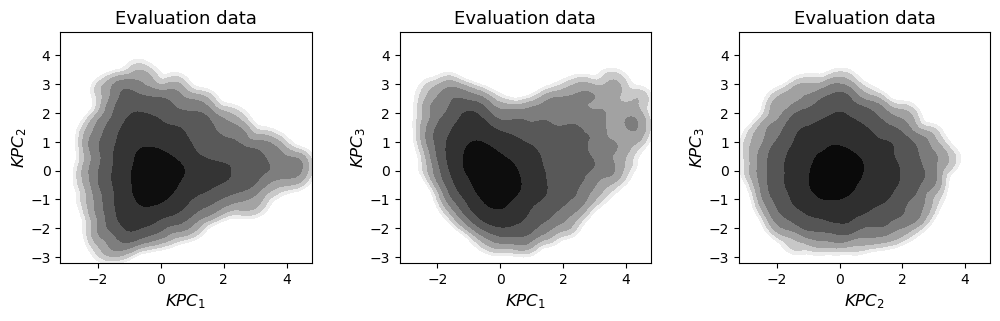

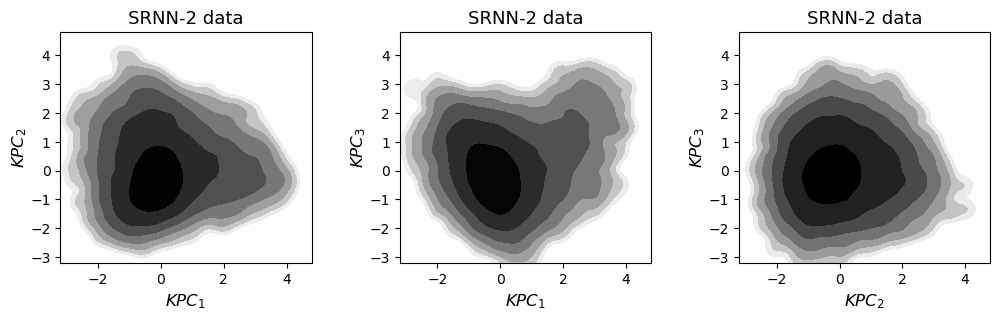

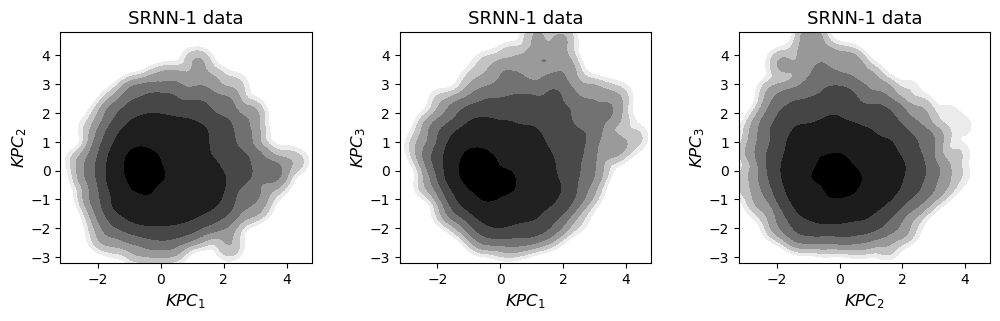

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3.5))
fig.subplots_adjust(
    left=0.06,
    right=0.99,
    bottom=0.22,
    wspace=0.35
)

k = 0
for i in range(3):
    for j in range(i + 1, 3):
        ax = axs[k]
        k += 1

        plot_kde2d(fig, ax,evaluation_kpcs[...,i],evaluation_kpcs[...,j])

        ax.set_xlabel(f"$KPC_{i+1}$", fontsize=12)
        ax.set_ylabel(f"$KPC_{j+1}$", fontsize=12, labelpad=1)
        ax.set_title('Evaluation data', fontsize=13)

        ax.set_xlim(-3.2, 4.8)
        ax.set_ylim(-3.2, 4.8)

plt.savefig('fig_kpcs_kde2d_eval.png', dpi=300)
plt.show()




fig, axs = plt.subplots(1, 3, figsize=(10, 3.5))
fig.subplots_adjust(
    left=0.06,
    right=0.99,
    bottom=0.22,
    wspace=0.35
)

k = 0
for i in range(3):
    for j in range(i + 1, 3):
        ax = axs[k]
        k += 1

        plot_kde2d(fig, ax,predicted_kpcs_a[...,i],predicted_kpcs_a[...,j])

        ax.set_xlabel(f"$KPC_{i+1}$", fontsize=12)
        ax.set_ylabel(f"$KPC_{j+1}$", fontsize=12, labelpad=1)
        ax.set_title('SRNN-2 data', fontsize=13)

        ax.set_xlim(-3.2, 4.8)
        ax.set_ylim(-3.2, 4.8)

plt.savefig('fig_kpcs_kde2d_srnn_a.png', dpi=300)
plt.show()







fig, axs = plt.subplots(1, 3, figsize=(10, 3.5))
fig.subplots_adjust(
    left=0.06,
    right=0.99,
    bottom=0.22,
    wspace=0.35
)

k = 0
for i in range(3):
    for j in range(i + 1, 3):
        ax = axs[k]
        k += 1

        plot_kde2d(fig, ax,predicted_kpcs_b[...,i],predicted_kpcs_b[...,j])

        ax.set_xlabel(f"$KPC_{i+1}$", fontsize=12)
        ax.set_ylabel(f"$KPC_{j+1}$", fontsize=12, labelpad=1)
        ax.set_title('SRNN-1 data', fontsize=13)

        ax.set_xlim(-3.2, 4.8)
        ax.set_ylim(-3.2, 4.8)

plt.savefig('fig_kpcs_kde2d_srnn_b.png', dpi=300)
plt.show()

##### **Plot observed and SRNN-a emulated relations of PCs and Kernel PCs (check that the PC - Kernel PC mapping is captured)**

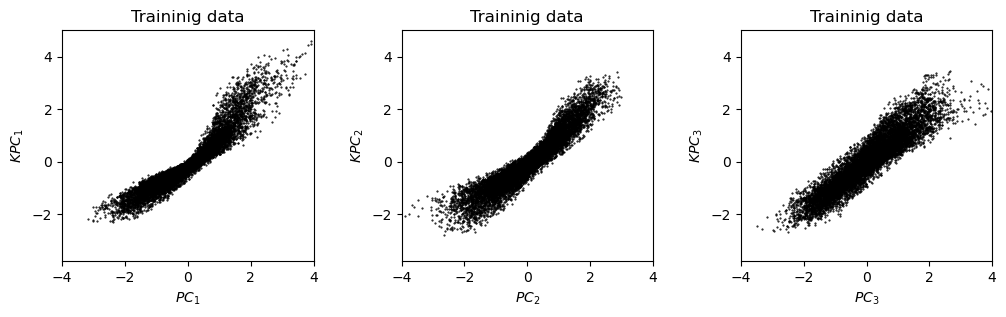

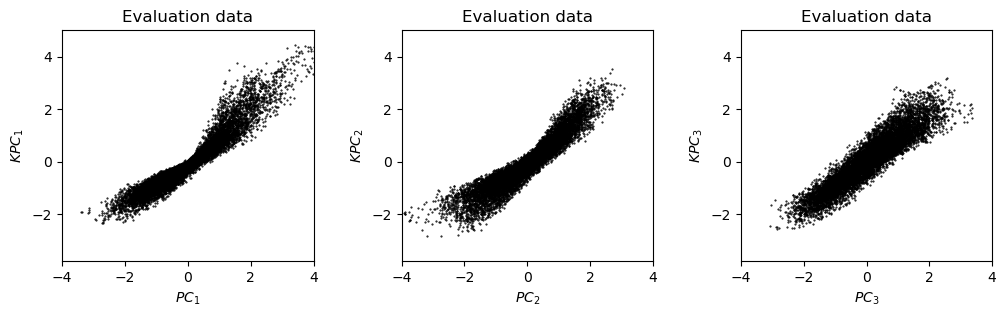

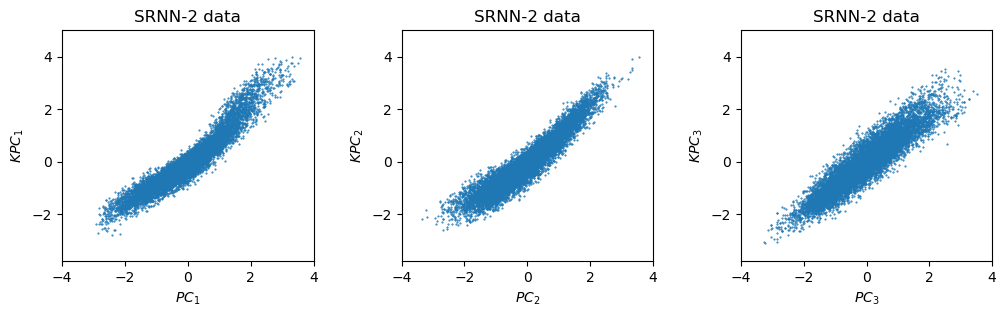

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3.5))
fig.subplots_adjust(
    left=0.06,
    right=0.99,
    bottom=0.22,
    wspace=0.35
)
k=0
for i in range(3):
    for j in [i]:
        ax=axs[k]
        k+=1
        ax.plot(pcs[:,:, i].flatten(), kpcs[:,:, j].flatten(),'.k',markersize=1)
        ax.set_xlabel(f"$PC_{i+1}$")
        ax.set_ylabel(f"$KPC_{j+1}$")
        ax.set_title('Traininig data')
        ax.set_xlim(-4,4)
        ax.set_ylim(-3.8,5.)
plt.savefig('fig_pc_kpc_map_tr')
plt.show()

fig, axs = plt.subplots(1, 3, figsize=(10, 3.5))
fig.subplots_adjust(
    left=0.06,
    right=0.99,
    bottom=0.22,
    wspace=0.35
)
k=0
for i in range(3):
    for j in [i]:
        ax=axs[k]
        k+=1
        ax.plot(evaluation_pcs[:,:, i].flatten(), evaluation_kpcs[:,:, j].flatten(),'.k',markersize=1)
        ax.set_xlabel(f"$PC_{i+1}$")
        ax.set_ylabel(f"$KPC_{j+1}$")
        ax.set_title('Evaluation data')
        ax.set_xlim(-4,4)
        ax.set_ylim(-3.8,5.)
plt.savefig('fig_pc_kpc_map_eval')
plt.show()

fig, axs = plt.subplots(1, 3, figsize=(10, 3.5))
fig.subplots_adjust(
    left=0.06,
    right=0.99,
    bottom=0.22,
    wspace=0.35
)
k=0
for i in range(3):
    for j in [i]:
        ax=axs[k]
        k+=1
        ax.plot(predicted_pcs_a[:,:, i].flatten(), predicted_kpcs_a[:,:, j].flatten(),'.',color='tab:blue',markersize=1)
        ax.set_xlabel(f"$PC_{i+1}$")
        ax.set_ylabel(f"$KPC_{j+1}$")
        ax.set_title('SRNN-2 data')
        ax.set_xlim(-4,4)
        ax.set_ylim(-3.8,5.)
plt.savefig('fig_pc_kpc_map_srnn_a')
plt.show()

##### **Plot short-term prediction skill**

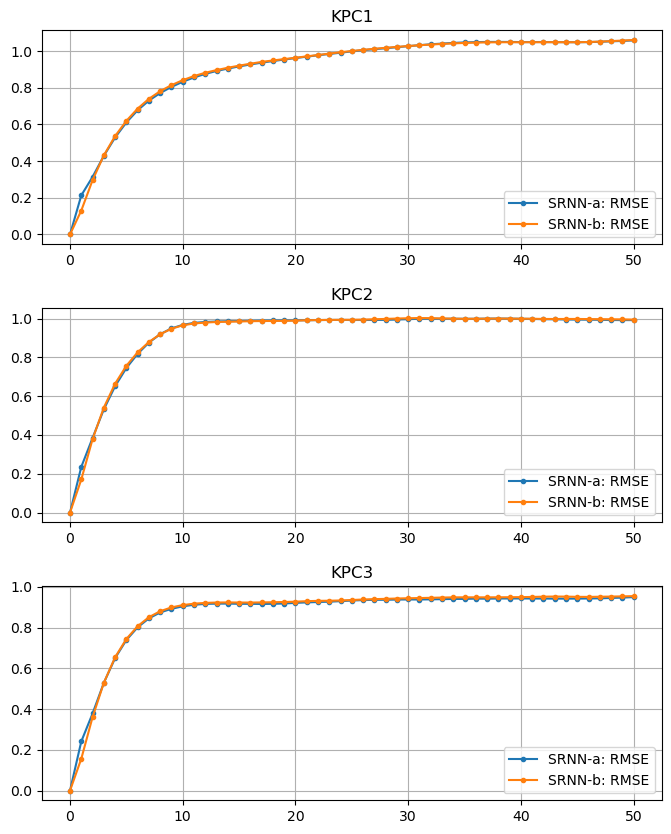

In [11]:
all_predicted_pcs,all_predicted_kpcs,all_observed_pcs,all_observed_kpcs=joblib.load(os.path.join(processed_data_path,'predicted_data_short_4a.jpkl'))
errors=all_predicted_kpcs-all_observed_kpcs
evaluation_data_mse_a=(errors**2).mean(axis=(0,1))

all_predicted_kpcs,all_observed_kpcs=joblib.load(os.path.join(processed_data_path,'predicted_data_short_4b.jpkl'))
errors=all_predicted_kpcs-all_observed_kpcs
evaluation_data_mse_b=(errors**2).mean(axis=(0,1))

nkpcs=evaluation_data_mse_a.shape[-1]
fig, axs = plt.subplots(nkpcs,1,figsize=(8,10))
fig.subplots_adjust(hspace=0.3)
for i in range(nkpcs):
    ax=axs[i]
    ax.set_title('KPC%d'%(i+1))
    #ax.plot(np.sqrt(training_data_mse[:,i]),'.-',label='training set RMSE')
    ax.plot(np.sqrt(evaluation_data_mse_a[:,i]),'.-',label='SRNN-a: RMSE')
    ax.plot(np.sqrt(evaluation_data_mse_b[:,i]),'.-',label='SRNN-b: RMSE')
    ax.legend()
    ax.grid(True)
plt.show()    
plt.close(fig) 

##### **Plot predictions vs. observations & difference in errors at specific lead time (pay attention to extreme events/tails)**

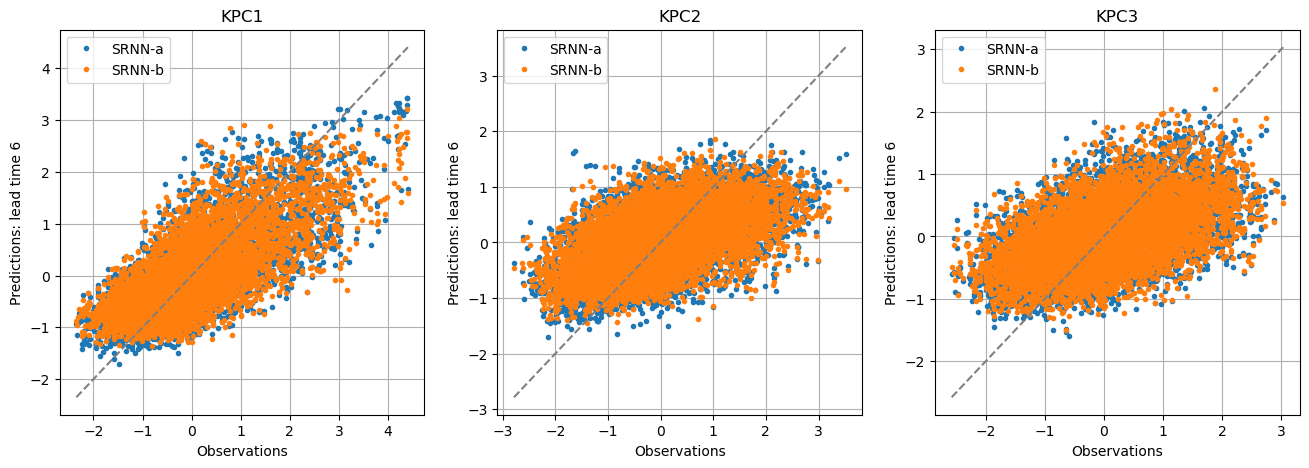

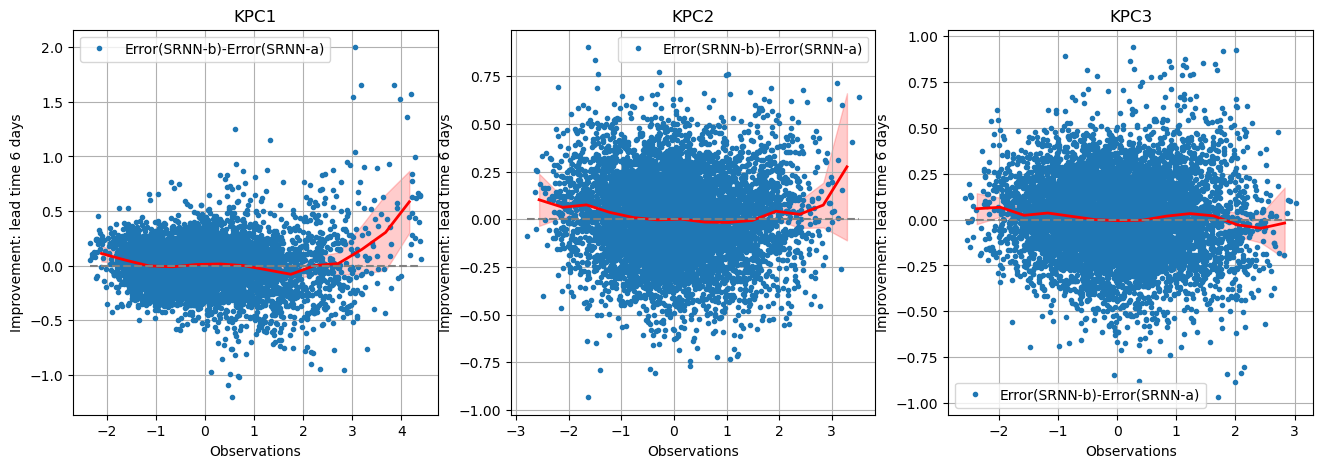

In [12]:
all_predicted_pcs,all_predicted_kpcs_a,all_observed_pcs,all_observed_kpcs_a=joblib.load(os.path.join(processed_data_path,'predicted_data_short_4a.jpkl'))
all_predicted_kpcs_b,all_observed_kpcs_b=joblib.load(os.path.join(processed_data_path,'predicted_data_short_4b.jpkl'))
t=6

nkpcs=evaluation_data_mse_a.shape[-1]
fig, axs = plt.subplots(1,nkpcs,figsize=(16,5))
fig.subplots_adjust(hspace=0.3)
for i in range(nkpcs):
    ax=axs[i]
    ax.set_title('KPC%d'%(i+1))
    #ax.plot(np.sqrt(training_data_mse[:,i]),'.-',label='training set RMSE')
    ax.plot(all_observed_kpcs_a[...,t,i].flatten(),all_predicted_kpcs_a[...,t,i].flatten(),'.',label='SRNN-a')
    ax.plot(all_observed_kpcs_b[...,t,i].flatten(),all_predicted_kpcs_b[...,t,i].flatten(),'.',label='SRNN-b')
    xx=np.linspace(np.amin(all_observed_kpcs_a[...,t,i]),np.amax(all_observed_kpcs_a[...,t,i]))
    ax.plot(xx,xx,'--',color='gray')
    ax.set_xlabel('Observations')
    ax.set_ylabel(f'Predictions: lead time {t}')
    ax.legend()
    ax.grid(True)
plt.show()    
plt.close(fig) 

fig, axs = plt.subplots(1,nkpcs,figsize=(16,5))
fig.subplots_adjust(hspace=0.3)
for i in range(nkpcs):
    ax=axs[i]
    ax.set_title('KPC%d'%(i+1))
    #ax.plot(np.sqrt(training_data_mse[:,i]),'.-',label='training set RMSE')

    x=all_observed_kpcs_a[...,t,i].flatten()
    y=np.abs(all_predicted_kpcs_b[...,t,i].flatten()-all_observed_kpcs_b[...,t,i].flatten())-np.abs(all_predicted_kpcs_a[...,t,i].flatten()-all_observed_kpcs_a[...,t,i].flatten())
    
    bins = np.linspace(x.min(), x.max(), 15)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    y_mean, y_sem = [], []

    for j in range(len(bins) - 1):
        yb = y[(x >= bins[j]) & (x < bins[j+1])]
        if len(yb):
            y_mean.append(yb.mean())
            y_sem.append(3*yb.std(ddof=1) / np.sqrt(len(yb)))
    ax.plot(x,y,'.',label='Error(SRNN-b)-Error(SRNN-a)')
    ax.plot(bin_centers[:len(y_mean)], y_mean, 'r-', lw=2)
    ax.fill_between(bin_centers[:len(y_mean)],
                 np.array(y_mean) - np.array(y_sem),
                 np.array(y_mean) + np.array(y_sem),
                 color='r', alpha=0.2)
    
    xx=np.linspace(np.amin(all_observed_kpcs_a[...,t,i]),np.amax(all_observed_kpcs_a[...,t,i]))
    ax.plot(xx,xx*0,'--',color='gray')
    ax.set_xlabel('Observations')
    ax.set_ylabel(f'Improvement: lead time {t} days')
    ax.legend()
    ax.grid(True)
plt.show()    
plt.close(fig) 

#### **Some conclusions**

- SRNN-a better captures the distribution tails for kernel PCs
- SRNN-a captures nonlinear relations between PCs and Kernel PCs
- Short term predictions are comparable, with signs of better accuracy of extreme event prediction for SRNN-a with increasing lead time. 

#### **Possible TODOs**

- It is possible to assess predicted probabilities of extreme events separately